# 🟦 Celda 1 — Importación de librerías

In [2]:
# ============================================
# 🧩 01. Importación de librerías necesarias
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Configuración visual
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

print("✅ Librerías importadas correctamente.")


✅ Librerías importadas correctamente.


# 🟦 Celda 2 — Carga del dataset

In [3]:
# ============================================
# 📥 02. Carga del dataset
# ============================================

# Cargamos el CSV que ya convertimos en el script anterior
df = pd.read_csv("../data/mushrooms.csv")

# Mostramos las primeras filas
df.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


# 🟦 Celda 3 — Información general del dataset

In [4]:
# ============================================
# ℹ️ 03. Exploración general del dataset
# ============================================

# Dimensiones del dataset
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes.value_counts())

# Conteo de valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum().sort_values(ascending=False))

# Información general
print("\nInformación general del DataFrame:")
df.info()


Filas: 8124 | Columnas: 23

Tipos de datos:
object    23
Name: count, dtype: int64

Valores nulos por columna:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Cou

# 🟦 Celda 4 — Análisis de la variable objetivo

C:\Users\yeder\AppData\Local\Temp\ipykernel_24956\4279239329.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', palette=['#66bb6a', '#ef5350'])


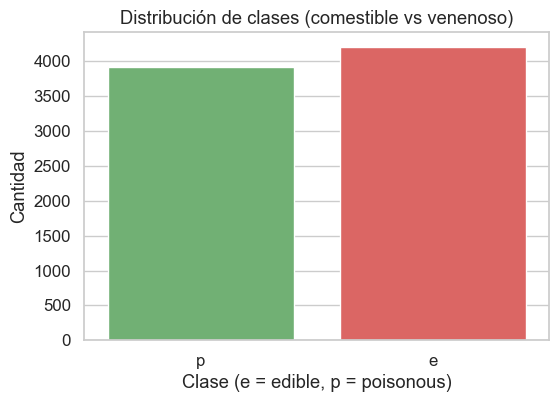

class
e    0.517971
p    0.482029
Name: proportion, dtype: float64

In [5]:
# ============================================
# 🎯 04. Análisis de la variable objetivo
# ============================================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='class', palette=['#66bb6a', '#ef5350'])
plt.title("Distribución de clases (comestible vs venenoso)")
plt.xlabel("Clase (e = edible, p = poisonous)")
plt.ylabel("Cantidad")
plt.show()

df['class'].value_counts(normalize=True)


# 🟦 Celda 5 — Distribución de valores únicos por columna

C:\Users\yeder\AppData\Local\Temp\ipykernel_24956\1605405950.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_counts.index, y=unique_counts.values, palette="viridis")


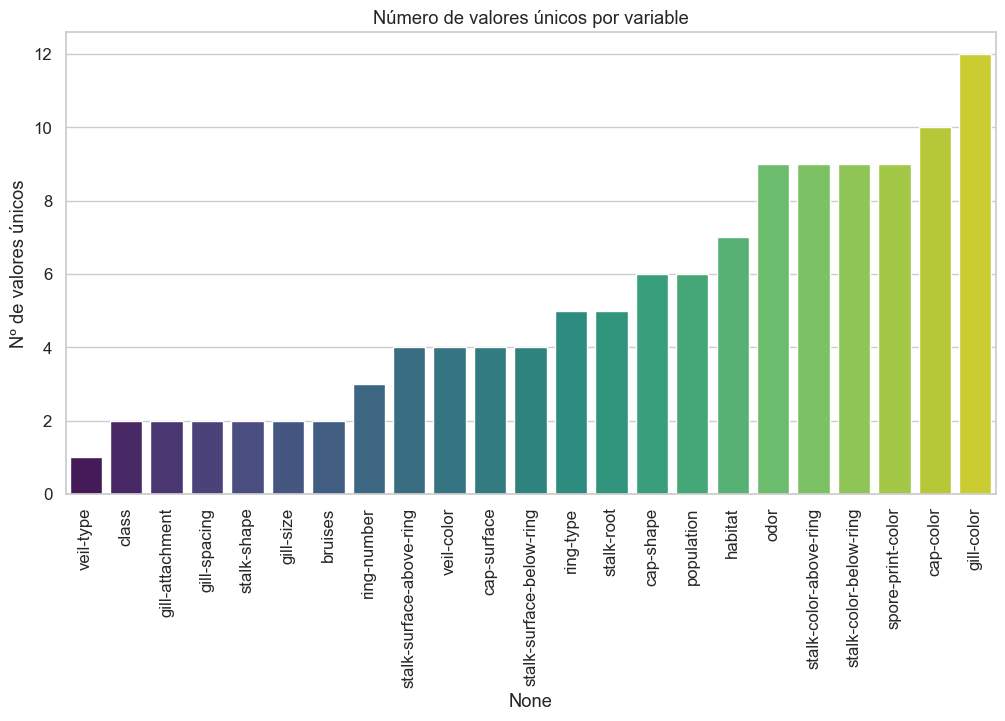

veil-type                    1
class                        2
gill-attachment              2
gill-spacing                 2
stalk-shape                  2
gill-size                    2
bruises                      2
ring-number                  3
stalk-surface-above-ring     4
veil-color                   4
cap-surface                  4
stalk-surface-below-ring     4
ring-type                    5
stalk-root                   5
cap-shape                    6
population                   6
habitat                      7
odor                         9
stalk-color-above-ring       9
stalk-color-below-ring       9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64

In [6]:
# ============================================
# 🔍 05. Valores únicos por variable
# ============================================

unique_counts = df.nunique().sort_values()

plt.figure(figsize=(12,6))
sns.barplot(x=unique_counts.index, y=unique_counts.values, palette="viridis")
plt.title("Número de valores únicos por variable")
plt.xticks(rotation=90)
plt.ylabel("Nº de valores únicos")
plt.show()

unique_counts


# 🟦 Celda 6 — Eliminación de columnas no informativas

In [7]:
# ============================================
# 🧼 06. Eliminación de columnas no informativas
# ============================================

# Buscamos columnas con solo un valor único
cols_constantes = [col for col in df.columns if df[col].nunique() == 1]
print("Columnas constantes:", cols_constantes)

# Eliminamos si existen
df.drop(columns=cols_constantes, inplace=True)
print(f"Dataset ahora tiene {df.shape[1]} columnas tras eliminar constantes.")


Columnas constantes: ['veil-type']
Dataset ahora tiene 22 columnas tras eliminar constantes.


# 🟦 Celda 7 — Análisis de correlación categórica (cramer’s V)

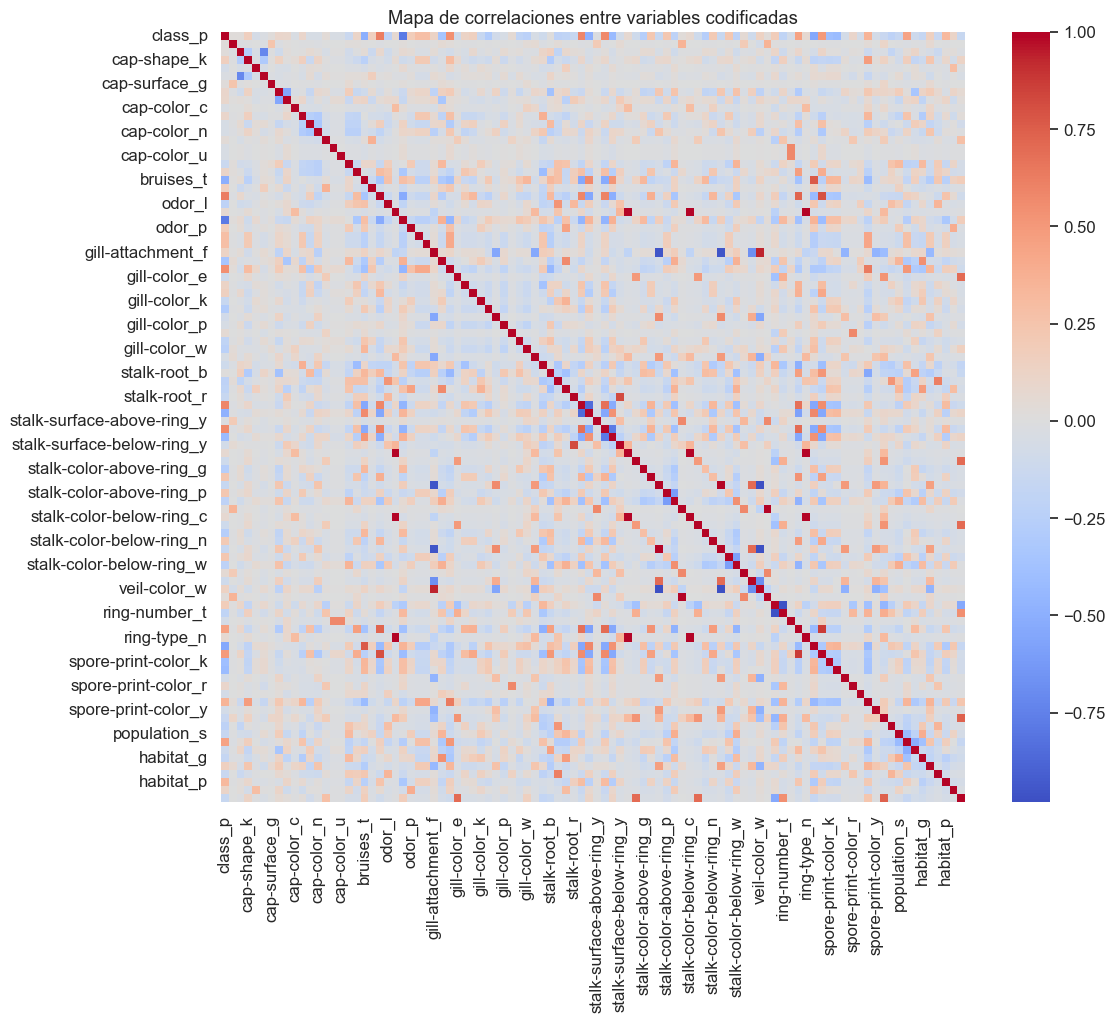

In [8]:
# ============================================
# 📊 07. Análisis de relación entre variables
# ============================================

# Convertimos a numérico temporalmente con pandas.get_dummies
df_dummies = pd.get_dummies(df, drop_first=True)

# Calculamos matriz de correlación
corr_matrix = df_dummies.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Mapa de correlaciones entre variables codificadas")
plt.show()


# 🟦 Celda 8 — Tratamiento de valores faltantes

In [9]:
# ============================================
# 🧩 08. Tratamiento de valores faltantes
# ============================================

missing = df.isnull().sum()
missing_cols = missing[missing > 0]
print("Columnas con valores faltantes:\n", missing_cols)

# En este dataset concreto, no suele haber nulos, pero si los hubiera:
df = df.dropna()

print(f"Dataset tras eliminar nulos: {df.shape}")


Columnas con valores faltantes:
 Series([], dtype: int64)
Dataset tras eliminar nulos: (8124, 22)


# 🟦 Celda 9 — Codificación de variables categóricas (One-Hot Encoding)

In [10]:
# ============================================
# 🔠 09. Codificación de variables categóricas
# ============================================

# Separamos variable objetivo y características
X = df.drop('class', axis=1)
y = df['class']

# Inicializamos OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Aplicamos codificación
X_encoded = encoder.fit_transform(X)

# Creamos un nuevo DataFrame con los nombres de columnas codificadas
encoded_cols = encoder.get_feature_names_out(X.columns)
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_cols)

print("✅ Codificación completada.")
print(f"Dimensiones originales: {X.shape}")
print(f"Dimensiones codificadas: {X_encoded_df.shape}")

X_encoded_df.head()


✅ Codificación completada.
Dimensiones originales: (8124, 21)
Dimensiones codificadas: (8124, 116)


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_b,cap-color_c,cap-color_e,cap-color_g,cap-color_n,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,bruises_f,bruises_t,odor_a,odor_c,odor_f,odor_l,odor_m,odor_n,odor_p,odor_s,odor_y,gill-attachment_a,gill-attachment_f,gill-spacing_c,gill-spacing_w,gill-size_b,gill-size_n,gill-color_b,gill-color_e,gill-color_g,gill-color_h,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stalk-shape_e,stalk-shape_t,stalk-root_?,stalk-root_b,stalk-root_c,stalk-root_e,stalk-root_r,stalk-surface-above-ring_f,stalk-surface-above-ring_k,stalk-surface-above-ring_s,stalk-surface-above-ring_y,stalk-surface-below-ring_f,stalk-surface-below-ring_k,stalk-surface-below-ring_s,stalk-surface-below-ring_y,stalk-color-above-ring_b,stalk-color-above-ring_c,stalk-color-above-ring_e,stalk-color-above-ring_g,stalk-color-above-ring_n,stalk-color-above-ring_o,stalk-color-above-ring_p,stalk-color-above-ring_w,stalk-color-above-ring_y,stalk-color-below-ring_b,stalk-color-below-ring_c,stalk-color-below-ring_e,stalk-color-below-ring_g,stalk-color-below-ring_n,stalk-color-below-ring_o,stalk-color-below-ring_p,stalk-color-below-ring_w,stalk-color-below-ring_y,veil-color_n,veil-color_o,veil-color_w,veil-color_y,ring-number_n,ring-number_o,ring-number_t,ring-type_e,ring-type_f,ring-type_l,ring-type_n,ring-type_p,spore-print-color_b,spore-print-color_h,spore-print-color_k,spore-print-color_n,spore-print-color_o,spore-print-color_r,spore-print-color_u,spore-print-color_w,spore-print-color_y,population_a,population_c,population_n,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

# 🟦 Celda 10 — Guardar datos procesados

In [14]:
# ============================================
# 💾 10. Guardado de datos procesados
# ============================================

# Guardamos los datos codificados en una nueva carpeta
import os

os.makedirs("../data/processed", exist_ok=True)

# Guardamos las features y la clase por separado
X_encoded_df.to_csv("../data/processed/X_encoded.csv", index=False)
y.to_csv("../data/processed/y.csv", index=False)

print("✅ Archivos guardados en data/processed/")


✅ Archivos guardados en data/processed/
